In [1]:
import sys
sys.path.append("..")
import os
import pandas as pd
from tqdm import tqdm
import numpy as np
import re
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

In [2]:
methods_names = {
    "dist_linguistic_confidence": "Dist. Ling. Conf.",
    "dist_semantic_uncertainty": "Dist. Semantic Unc.",
    "dist_lnll": "Dist. Token Prob"
}

dataset_map = {
    "mmlu": "MMLU",
    "squadv2": "SQuADv2.0",
    "truth_qa": "TruthfulQA"
}

model_name_map = {
    "Llama-3.1-8B-Instruct": "Llama-3.1-8B-Inst.",
    "Meta-Llama-3-8B-Instruct": "Llama-3-8B-Inst.",
    "Qwen2.5-7B-Instruct": "Qwen2.5-7B-Inst.",
    "Qwen3-8B": "Qwen3-8B-Inst.",
    "Mistral-7B-Instruct-v0.3": "Mistral-7B-Inst.",
    "gpt-oss-20b": "GPT-OSS-20B",
}

In [3]:
results_dir = f"/hdd/ivny/direct_qa_in_domain_calibration"

# list all leaf nodes in results_dir
leaf_dirs = []
for root, dirs, files in os.walk(results_dir):
    if not dirs:  # if there are no subdirectories, it's a leaf node
        leaf_dirs.append(root)

def extract_signal_mean(signal_str):
    # signal_str format: "mu=0.123, sigma=0.456"
    match = re.search(r"mu=([0-9.]+)", str(signal_str))
    if match:
        return float(match.group(1))
    return None

estimators = {
    "lc": {
        "signal_col": "calibrated_lc",
        "rewritten_lc_col": "calibrated_lc_rewritten_lc",
        "rewritten_response_col": "calibrated_lc_rewritten_response",
    },
    "tp": {
        "signal_col": "calibrated_tp",
        "rewritten_lc_col": "calibrated_tp_rewritten_lc",
        "rewritten_response_col": "calibrated_tp_rewritten_response",
    },
    "su": {
        "signal_col": "calibrated_su",
        "rewritten_lc_col": "calibrated_su_rewritten_lc",
        "rewritten_response_col": "calibrated_su_rewritten_response",
    },
}

estimator_label_map = {
    "lc": "Linguistic Confidence",
    "tp": "Token Probability",
    "su": "Semantic Uncertainty",
}

estimator_data = {
    key: {
        "signal_means": [],
        "lc_means": [],
        "original_response": [],
        "calibrated_response": [],
    }
    for key in estimators
}

for leaf_dir in leaf_dirs:
    _, _, _, _, dataset_name, _, model_name = leaf_dir.split("/")
    calibration_path = os.path.join(leaf_dir, "calibration_details.csv")

    if not os.path.exists(calibration_path):
        print(dataset_name, model_name, "calibration_details.csv not found")
        continue

    csv_data = pd.read_csv(calibration_path, index_col=0)

    for est_key, est_cfg in estimators.items():
        estimator_data[est_key]["original_response"] += csv_data["original_response"].astype(str).tolist()
        estimator_data[est_key]["calibrated_response"] += csv_data[est_cfg["rewritten_response_col"]].astype(str).tolist()
        estimator_data[est_key]["signal_means"] += csv_data[est_cfg["signal_col"]].apply(extract_signal_mean).tolist()
        estimator_data[est_key]["lc_means"] += csv_data[est_cfg["rewritten_lc_col"]].apply(extract_signal_mean).tolist()

# Optional pooled arrays for backward compatibility with downstream cells.
signal_means = []
lc_means = []
original_response = []
calibrated_response = []
for est_key in ["lc", "tp", "su"]:
    signal_means += estimator_data[est_key]["signal_means"]
    lc_means += estimator_data[est_key]["lc_means"]
    original_response += estimator_data[est_key]["original_response"]
    calibrated_response += estimator_data[est_key]["calibrated_response"]

In [4]:
def spearman_with_binning(x, y, n_bins=20, agg='mean'):
    df = pd.DataFrame({'x': x, 'y': y})

    # Create quantile-based bins
    df['bin'] = pd.qcut(df['x'], q=n_bins, duplicates='drop')

    # Aggregate within bins
    if agg == 'mean':
        grouped = df.groupby('bin', observed=True).mean(numeric_only=True)
    elif agg == 'median':
        grouped = df.groupby('bin', observed=True).median(numeric_only=True)
    else:
        raise ValueError("agg must be 'mean' or 'median'")

    # Compute Spearman on aggregated points
    rho, p = spearmanr(grouped['x'], grouped['y'])

    return rho, p, grouped

In [5]:
# Combined figure: one row per estimator, with correlation (left) and entailment distribution (right)
import scipy.special as sp
from sentence_transformers import CrossEncoder

def _clean_xy(x_vals, y_vals):
    x_vals = np.asarray(x_vals, dtype=float)
    y_vals = np.asarray(y_vals, dtype=float)
    n = min(len(x_vals), len(y_vals))
    x_vals = x_vals[:n]
    y_vals = y_vals[:n]
    mask = np.isfinite(x_vals) & np.isfinite(y_vals)
    return x_vals[mask], y_vals[mask]

def build_entailment_scores_by_estimator(
    estimator_data,
    row_order,
    max_pairs=5000,
    random_seed=42,
    model_name="cross-encoder/nli-deberta-v3-base",
    device="cpu",
    batch_size=1,
    show_progress_bar=True,
    neutral_weight=0.5,
    ):
    model = CrossEncoder(model_name, device=device)
    entailment_scores = {}

    for est_key in row_order:
        data = estimator_data[est_key]
        pairs = [
            (str(calibrated), str(original))
            for original, calibrated in zip(
                data["original_response"], data["calibrated_response"]
            )
        ]

        # Randomly sample at most max_pairs pairs for efficiency.
        if len(pairs) > max_pairs:
            rng = np.random.default_rng(random_seed)
            indices = rng.choice(len(pairs), size=max_pairs, replace=False)
            pairs = [pairs[i] for i in indices]

        if not pairs:
            entailment_scores[est_key] = np.array([], dtype=float)
            continue

        logits = model.predict(
            pairs,
            batch_size=batch_size,
            show_progress_bar=show_progress_bar,
            device=device,
        )
        probs = sp.softmax(logits, axis=1)
        entailment_scores[est_key] = probs[:, 1] + neutral_weight * probs[:, 2]
    del model
    return entailment_scores

row_order = ["lc", "tp", "su"]

# Step 1: Run entailment model once and cache scores by estimator for reuse.
entailment_scores_by_estimator = build_entailment_scores_by_estimator(
    estimator_data=estimator_data,
    row_order=row_order,
    max_pairs=5000,
    random_seed=42,
    device="cuda",
    batch_size=5,
    show_progress_bar=True,
    neutral_weight=0.5,
    )


/home/ivan/miniconda3/envs/llm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 1000/1000 [00:14<00:00, 71.26it/s]


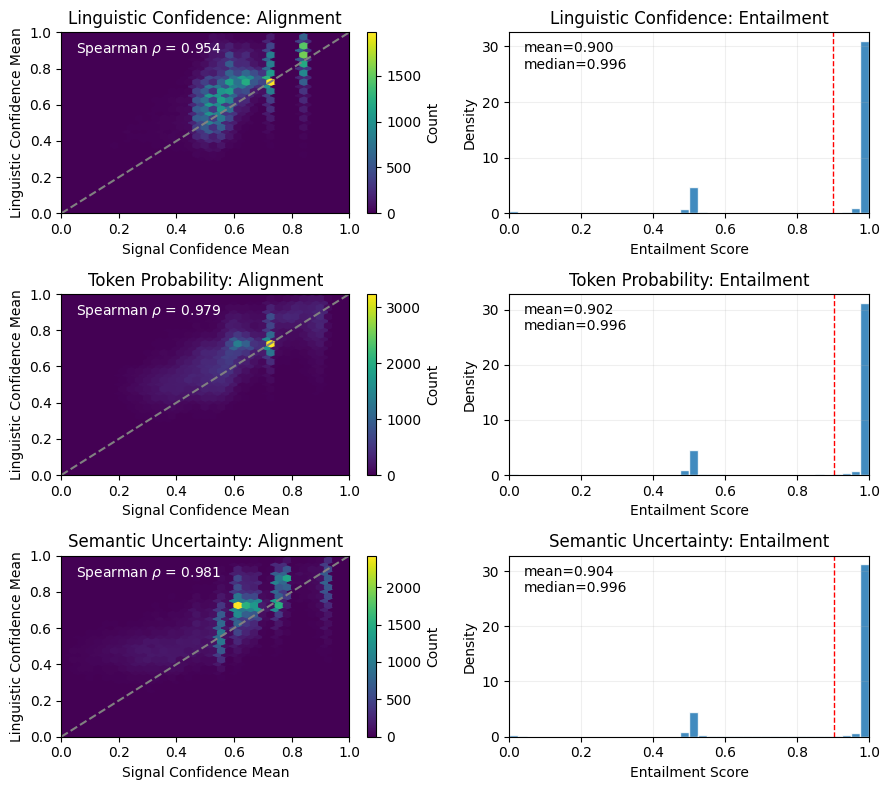

In [15]:

# Step 2: Build figure using cached entailment scores.
fig, axes = plt.subplots(3, 2, figsize=(9, 8))

for row_idx, est_key in enumerate(row_order):
    est_label = estimator_label_map.get(est_key, est_key.upper())
    data = estimator_data[est_key]

    # ---- Left: bin-smoothed correlation via hexbin ----
    x_est, y_est = _clean_xy(data["signal_means"], data["lc_means"])
    rho_est, _, _ = spearman_with_binning(x_est, y_est, n_bins=500)

    ax_left = axes[row_idx, 0]
    hb = ax_left.hexbin(
        x_est,
        y_est,
        gridsize=35,
        extent=(0, 1, 0, 1),
    )
    ax_left.plot([0, 1], [0, 1], linestyle="--", color="grey")
    ax_left.set_xlim(0, 1)
    ax_left.set_ylim(0, 1)
    ax_left.set_xlabel("Signal Confidence Mean")
    ax_left.set_ylabel("Linguistic Confidence Mean")
    ax_left.set_title(f"{est_label}: Alignment")
    ax_left.text(
        0.05,
        0.95,
        fr"Spearman $\rho$ = {rho_est:.3f}",
        transform=ax_left.transAxes,
        va="top",
        color="white",
    )
    cb = fig.colorbar(hb, ax=ax_left)
    cb.set_label("Count")

    # ---- Right: entailment distribution (from cached inference outputs) ----
    similarities_est = entailment_scores_by_estimator.get(est_key, np.array([], dtype=float))

    ax_right = axes[row_idx, 1]
    bins = np.linspace(0.0, 1.0, 41)
    if len(similarities_est) > 0:
        ax_right.hist(similarities_est, bins=bins, density=True, alpha=0.85, edgecolor="white")
        ax_right.axvline(np.mean(similarities_est), linestyle="--", linewidth=1, color="red")
        summary_text = (
            f"mean={np.mean(similarities_est):.3f}\n"
            f"median={np.median(similarities_est):.3f}"
        )
    else:
        summary_text = "n=0\nmean=NA\nmedian=NA"

    ax_right.set_xlim(0, 1)
    ax_right.set_xlabel("Entailment Score")
    ax_right.set_ylabel("Density")
    ax_right.set_title(f"{est_label}: Entailment")
    ax_right.grid(alpha=0.2)
    ax_right.text(
        0.04,
        0.95,
        summary_text,
        transform=ax_right.transAxes,
        va="top",
        ha="left",
    )

plt.tight_layout()
plt.savefig("direct_qa_linguistic-calibration-quality-by-estimator.pdf", dpi=300, bbox_inches="tight")
plt.show()